In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
X = df[["ram", "battery_power"]].values
y = df["price_range"].values

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Kelas:", np.unique(y))

Shape X: (2000, 2)
Shape y: (2000,)
Kelas: [0 1 2 3]


In [5]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std

In [6]:
num_classes = 4
y_onehot = np.eye(num_classes)[y]

print("Contoh label asli:", y[:5])
print("Contoh one-hot:\n", y_onehot[:5])

Contoh label asli: [1 2 2 2 1]
Contoh one-hot:
 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]


In [7]:
def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

In [8]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.sum(y_true * np.log(y_pred))

In [9]:
num_features = X.shape[1]
num_classes = 4

W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)

learning_rate = 0.01
epochs = 100
loss_history = []

In [10]:
n = len(X)

for epoch in range(epochs):
    total_loss = 0

    for i in range(n):
        xi = X[i]
        yi = y_onehot[i]

        z = np.dot(xi, W) + b
        y_pred = softmax(z)

        loss = cross_entropy_loss(yi, y_pred)
        total_loss += loss

        grad_z = y_pred - yi

        grad_W = np.outer(xi, grad_z)

        grad_b = grad_z

        W = W - learning_rate * grad_W
        b = b - learning_rate * grad_b

    avg_loss = total_loss / n
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 10, Loss: 0.4547
Epoch 20, Loss: 0.4182
Epoch 30, Loss: 0.4067
Epoch 40, Loss: 0.4018
Epoch 50, Loss: 0.3994
Epoch 60, Loss: 0.3981
Epoch 70, Loss: 0.3974
Epoch 80, Loss: 0.3970
Epoch 90, Loss: 0.3967
Epoch 100, Loss: 0.3966


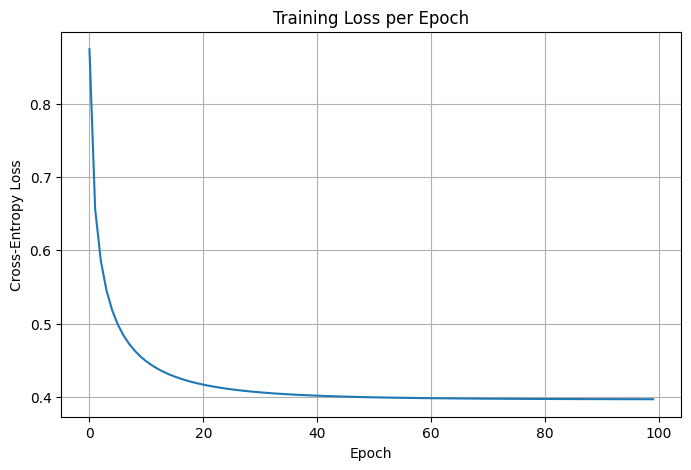

In [11]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()

In [12]:
def predict(X, W, b):
    predictions = []
    for xi in X:
        z = np.dot(xi, W) + b
        probs = softmax(z)
        pred_class = np.argmax(probs)
        predictions.append(pred_class)
    return np.array(predictions)

In [13]:
y_pred_class = predict(X, W, b)
accuracy = np.mean(y_pred_class == y)

print("Training Accuracy:", accuracy)

Training Accuracy: 0.8235


In [14]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_pred = predict(grid_points, W, b)
grid_pred = grid_pred.reshape(xx.shape)

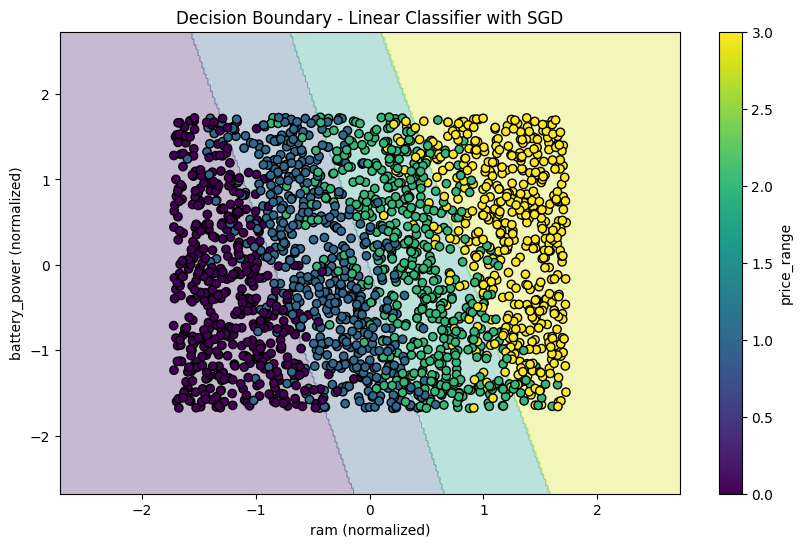

In [15]:
plt.figure(figsize=(10,6))

plt.contourf(xx, yy, grid_pred, alpha=0.3)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.title("Decision Boundary - Linear Classifier with SGD")
plt.xlabel("ram (normalized)")
plt.ylabel("battery_power (normalized)")
plt.colorbar(scatter, label="price_range")
plt.show()